In [12]:

import sys
sys.path.append("..")
sys.path.append("../api")

from api.AirbnbRemoteData import AirbnbRemoteData

berlin_listings_url = "https://data.insideairbnb.com/germany/be/berlin/2025-09-23/visualisations/listings.csv"
munich_listing_url = "https://data.insideairbnb.com/germany/bv/munich/2025-09-27/visualisations/listings.csv"

airbnb_fetcher = AirbnbRemoteData(berlin_listings_url, munich_listing_url)
airbnb_fetcher.fetch_data()

In [13]:
columns_df_a = airbnb_fetcher.get_berlin_data_frame_columns()
print(columns_df_a)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'city'],
      dtype='object')


In [14]:
columns_df_b = airbnb_fetcher.get_munich_data_frame_columns()
print(columns_df_b)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'city'],
      dtype='object')


In [15]:
merged_df = airbnb_fetcher.get_combined_data()
if merged_df is not None:
    print(f"Successfully merged!")
    display(merged_df.head(500))
else:
    print("Merge failed. Check if the CSVs share a common column name (like 'id' or 'listing_id').")

Successfully merged!


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,150,2025-08-09,0.76,1,140,2,First name and Last name: Nicolas Krotz <br/> ...,Berlin
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,135.0,6,7,2020-01-04,0.06,1,241,0,03/Z/RA/003410-18,Berlin
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,75.0,150,26,2023-11-30,0.14,4,168,0,NaN,Berlin
3,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,32.0,93,298,2025-09-02,1.57,1,72,1,NaN,Berlin
4,20858,Designer Loft in Berlin Mitte,71331,Marc,Pankow,Prenzlauer Berg Südwest,52.53711,13.40888,Entire home/apt,202.0,3,140,2025-07-16,0.89,1,253,4,03/Z/RA/009767-24,Berlin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2137277,Modern + Renovated + Cool Kreuzberg,10692949,Suites And More,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,52.48980,13.41917,Entire home/apt,76.0,2,392,2025-08-29,2.83,3,232,31,First name and Last name: Magdalena Rynkar <br...,Berlin
496,2140695,Cozy Apartment in the vibrant heart of Berlin,4314868,Katharina,Pankow,Prenzlauer Berg Nordwest,52.54845,13.40299,Entire home/apt,63.0,92,74,2022-09-30,0.53,1,343,0,NaN,Berlin
497,2147777,Moabit apartment,10962834,Katharina,Mitte,Moabit West,52.53494,13.34055,Entire home/apt,73.0,2,301,2025-09-21,2.37,1,327,36,01/Z/ZA/006223-16,Berlin
498,2154488,4th floor on the Island,10986253,Oliver,Tempelhof - Schöneberg,Schöneberg-Süd,52.48348,13.36133,Private room,49.0,3,136,2025-08-29,0.99,1,107,15,07/Z/AZ/019980-25,Berlin


In [16]:
merged_df['city'].value_counts()

city
Berlin    14274
Munich     8274
Name: count, dtype: int64

In [17]:
list(merged_df.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'license',
 'city']

In [20]:
# the columns need to keep for analysis:price 

columns_to_keep = [
    'price',
    'room_type',
    'neighbourhood','city',
    'minimum_nights',
    'number_of_reviews','reviews_per_month','availability_365'
]
print(columns_to_keep)

['price', 'room_type', 'neighbourhood', 'city', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']


In [21]:
merged_df = merged_df[columns_to_keep]

merged_df



,price,room_type,neighbourhood,city,minimum_nights,number_of_reviews,reviews_per_month,availability_365
0,105.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,63,150,0.76,140
1,135.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,6,7,0.06,241
2,75.0,Entire home/apt,Prenzlauer Berg Nordwest,Berlin,150,26,0.14,168
3,32.0,Entire home/apt,Reuterstraße,Berlin,93,298,1.57,72
4,202.0,Entire home/apt,Prenzlauer Berg Südwest,Berlin,3,140,0.89,253
...,...,...,...,...,...,...,...,...
22543,427.0,Entire home/apt,Neuhausen-Nymphenburg,Munich,1,0,NaN,17
22544,152.0,Entire home/apt,Ludwigsvorstadt-Isarvorstadt,Munich,1,0,NaN,150
22545,200.0,Private room,Ludwigsvorstadt-Isarvorstadt,Munich,1,0,NaN,1
22546,120.0,Private room,Schwabing-Freimann,Munich,1,0,NaN,364


In [33]:
(merged_df ["price"]>1000).any()


np.True_

In [34]:
(merged_df ["price"]>1000).sum()


np.int64(148)

In [35]:
(merged_df ["price"]<0).any()


np.False_

<Axes: ylabel='Frequency'>

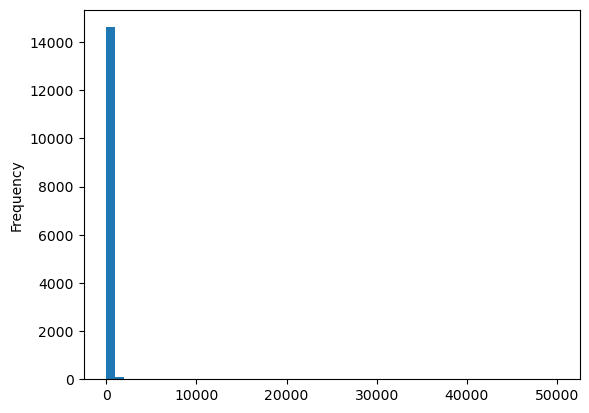

In [26]:
df1=merged_df
df1.isnull().sum()
(df1.isnull().sum() / len(df1)) * 100
df2 = df1.dropna(subset=["price"]) # droping according to price
(df2.isnull().sum() / len(df2)) * 100

#df2.shape

## Dealing with duplicates ################
df2.duplicated().sum()
df3 = df2.drop_duplicates()
df3.duplicated().sum()

#df3.shape

## plotting price ###################
import matplotlib.pyplot as plt
df3["price"].plot(kind="hist", bins=50)
#df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50) 
#Message berlin_team_1

<Axes: ylabel='Frequency'>

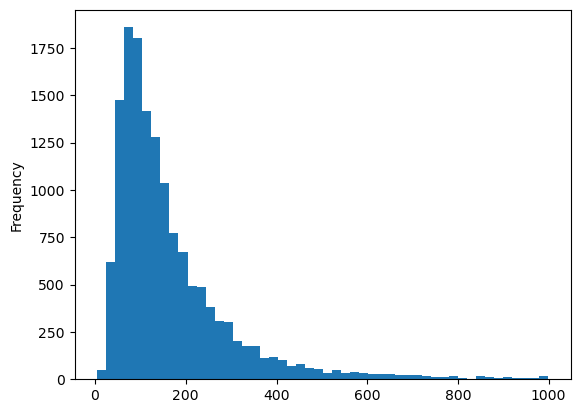

In [27]:
df3[df3["price"] < 1000]["price"].plot(kind="hist", bins=50)